In [1]:
library(patchwork)
library(viridis)


#####################
## Define settings ##
#####################
here::i_am("processing/1_create_seurat_rna.R")
source(here::here("settings.R"))
source(here::here("utils.R"))

Loading required package: viridisLite

here() starts at /rds/project/rds-SDzz0CATGms/users/bt392/03_Stat3_RNA/code



In [2]:
args = list()
args$sce <- io$rna.sce
args$metadata <- file.path(io$basedir,"results/rna/mapping/sample_metadata_after_mapping.txt.gz")
args$atlas_metadata <- "/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/extended/sample_metadata.txt.gz"
args$outdir <- file.path(io$basedir,"results/rna/plots")
dir.create(args$outdir, recursive=TRUE, showWarnings = FALSE)


In [3]:
##########################
## Load sample metadata ##
##########################

sample_metadata <- fread(args$metadata) %>%
   .[pass_rnaQC==TRUE & doublet_call==FALSE]

###############
## Load data ##
###############

# Load RNA expression data as SingleCellExperiment object
 sce <- load_SingleCellExperiment(args$sce, cells=sample_metadata$cell, normalise = TRUE)

# # Add sample metadata as colData
 colData(sce) <- sample_metadata %>% tibble::column_to_rownames("cell") %>% DataFrame

In [4]:
# Atlas umap
umap_atlas = fread(args$atlas_metadata)[,c('cell', 'umapX', 'umapY', 'celltype')]
umap_mapped = data.table(actual_cell = sample_metadata$cell, cell = sample_metadata$closest.cell_mnn) %>% 
    .[,idx:=1:nrow(.)] %>%
    merge(umap_atlas, by='cell') %>% 
    .[order(idx), c('actual_cell', 'umapX', 'umapY')] %>% 
    tibble::column_to_rownames("actual_cell") %>% tibble::rownames_to_column("cell")

In [5]:
meta = sample_metadata %>%
    merge(umap_mapped, by='cell') 

In [105]:
# plot mapped celltypes
p = ggplot(meta, aes(umapX, umapY, col=celltype.mapped_mnn)) + 
    geom_point(data=umap_atlas[sample(nrow(umap_atlas), nrow(umap_atlas)/10)], aes(umapX, umapY), col='gray90') +
    geom_point(alpha=0.6) +
    scale_color_manual(values=opts$celltype.colors) + 
    xlim(min(umap_atlas$umapX), max(umap_atlas$umapX)) + ylim(min(umap_atlas$umapY), max(umap_atlas$umapY)) +
    ggtitle('celltype mapped') + 
    theme_void() + theme(legend.position='none')

outfile <- file.path(args$outdir,'celltypes_umap.pdf')
pdf(outfile, width=8, height=8)
 p
dev.off()

# plot mapping scores
p = ggplot(meta, aes(umapX, umapY, col=celltype.score_mnn)) + 
    geom_point(data=umap_atlas[sample(nrow(umap_atlas), nrow(umap_atlas)/10)], aes(umapX, umapY), col='gray90') +
    geom_point(alpha=0.6) +
    scale_color_viridis() + 
    xlim(min(umap_atlas$umapX), max(umap_atlas$umapX)) + ylim(min(umap_atlas$umapY), max(umap_atlas$umapY)) +
    ggtitle('stages') + 
    theme_void() 

outfile <- file.path(args$outdir,'mapping_score_umap.pdf')
pdf(outfile, width=8, height=8)
 p
dev.off()

# plot stages
p = ggplot(meta, aes(umapX, umapY, col=stage)) + 
    geom_point(data=umap_atlas[sample(nrow(umap_atlas), nrow(umap_atlas)/10)], aes(umapX, umapY), col='gray90') +
    geom_point(alpha=0.6) +
    scale_color_manual(values=opts$stage.colors) + 
    xlim(min(umap_atlas$umapX), max(umap_atlas$umapX)) + ylim(min(umap_atlas$umapY), max(umap_atlas$umapY)) +
    ggtitle('stages') + 
    theme_void() + theme(legend.position='none')

outfile <- file.path(args$outdir,'stages_umap.pdf')
pdf(outfile, width=8, height=8)
 p
dev.off()

# plot tdTomato 
p = ggplot(meta, aes(umapX, umapY, col=tdTom_corr)) + 
    geom_point(data=umap_atlas[sample(nrow(umap_atlas), nrow(umap_atlas)/10)], aes(umapX, umapY), col='gray90') +
    geom_point(alpha=0.6) +
    scale_color_manual(values=opts$tdTom.color) + 
    xlim(min(umap_atlas$umapX), max(umap_atlas$umapX)) + ylim(min(umap_atlas$umapY), max(umap_atlas$umapY)) +
    ggtitle('TdTomato') + 
    theme_void() + theme(legend.position='none')

outfile <- file.path(args$outdir,'tdTom_umap.pdf')
pdf(outfile, width=8, height=8)
 p
dev.off()

png 
  2

png 
  2

png 
  2

png 
  2

In [98]:
p = list()
for(celltype in sort(unique(meta$celltype.mapped_mnn))){
p[[celltype]] = ggplot(meta[celltype.mapped_mnn == celltype,], aes(umapX, umapY, col=stage)) + 
    geom_point(data=umap_atlas[sample(nrow(umap_atlas), nrow(umap_atlas)/10)], aes(umapX, umapY), col='gray90') +
    geom_point(alpha=0.6) +
    scale_color_manual(values=opts$stage.colors) + 
    xlim(min(umap_atlas$umapX), max(umap_atlas$umapX)) + ylim(min(umap_atlas$umapY), max(umap_atlas$umapY)) +
    ggtitle(celltype) + 
    theme_void() + theme(legend.position='none')
    }

In [99]:
outfile <- file.path(args$outdir,'celltypes_individual_umap.pdf')
pdf(outfile, width=8, height=8)
 p
dev.off()

$Allantois

$`Allantois endothelium`

$`Amniotic ectoderm`

$`Anterior cardiopharyngeal progenitors`

$`Anterior Primitive Streak`

$`Anterior somitic tissues`

$`Blood progenitors`

$`Branchial arch neural crest`

$`Cardiomyocytes FHF 1`

$`Cardiomyocytes FHF 2`

$`Cardiomyocytes SHF 1`

$`Cardiomyocytes SHF 2`

$`Cardiopharyngeal progenitors`

$`Cardiopharyngeal progenitors FHF`

$`Cardiopharyngeal progenitors SHF`

$`Caudal epiblast`

$`Caudal mesoderm`

$`Chorioallantoic-derived erythroid progenitors`

$`Cranial mesoderm`

$Dermomyotome

$`Dorsal hindbrain progenitors`

$`Dorsal midbrain neurons`

$`Dorsal spinal cord progenitors`

$`Early dorsal forebrain progenitors`

$Ectoderm

$`Embryo proper endothelium`

$`Embryo proper mesothelium`

$EMP

$Endocardium

$Epiblast

$Epicardium

$Epidermis

$Erythroid

$`ExE ectoderm`

$`ExE endoderm`

$Foregut

$Forelimb

$`Frontonasal mesenchyme`

$`Gut tube`

$`Haematoendothelial progenitors`

$`Hindbrain floor plate`

$`Hindbrain neural pro

png 
  2

In [100]:
p = list()
for(stages in sort(unique(meta$stage))){
p1 = ggplot(meta[stage == stages,], aes(umapX, umapY, col=celltype.mapped_mnn)) + 
    geom_point(data=umap_atlas[sample(nrow(umap_atlas), nrow(umap_atlas)/10)], aes(umapX, umapY), col='gray90') +
    geom_point(alpha=0.6) +
    scale_color_manual(values=opts$celltype.colors) + 
    xlim(min(umap_atlas$umapX), max(umap_atlas$umapX)) + ylim(min(umap_atlas$umapY), max(umap_atlas$umapY)) +
    ggtitle(stages) + 
    theme_void() + theme(legend.position='none')
    
p2 = ggplot(meta[stage == stages,], aes(umapX, umapY, col=tdTom_corr)) + 
    geom_point(data=umap_atlas[sample(nrow(umap_atlas), nrow(umap_atlas)/10)], aes(umapX, umapY), col='gray90') +
    geom_point(alpha=0.6) +
    scale_color_manual(values=opts$tdTom.color) + 
    xlim(min(umap_atlas$umapX), max(umap_atlas$umapX)) + ylim(min(umap_atlas$umapY), max(umap_atlas$umapY)) +
    ggtitle(stages) + 
    theme_void() + theme(legend.position='none')
p[[stages]] = p1 + p2
    }

In [101]:
outfile <- file.path(args$outdir,'stages__individual_umap.pdf')
pdf(outfile, width=13, height=8)
 p
dev.off()

$E7.5

$E8.5

$E9.5


png 
  2

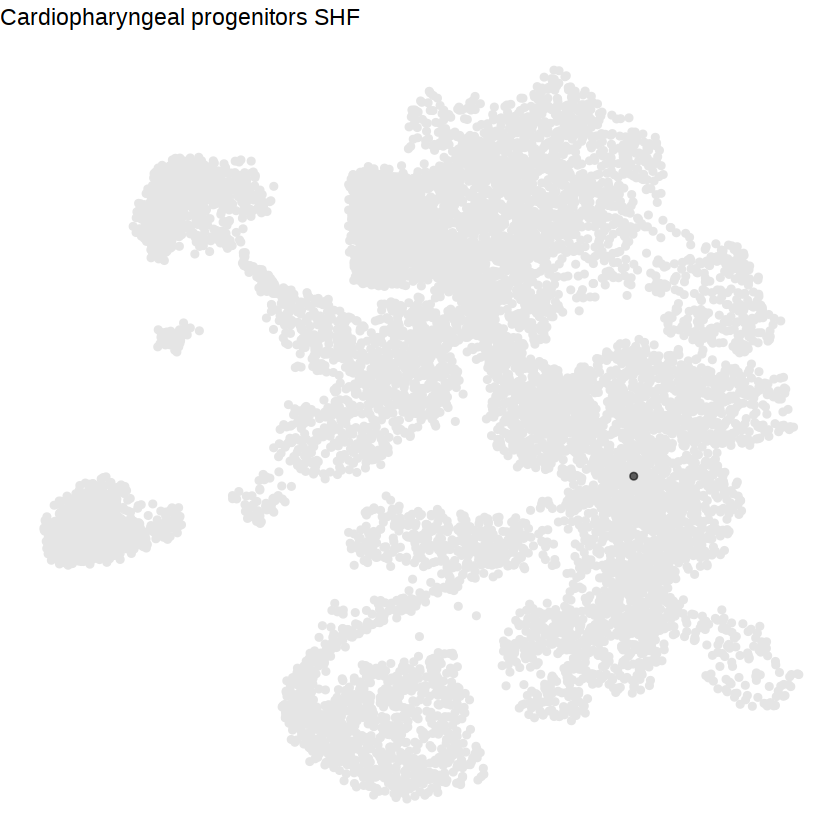

In [51]:
cell_plot = 'cell_13206'
ggplot(umap_atlas[cell == cell_plot,], aes(umapX, umapY)) + 
    geom_point(data=umap_atlas[sample(nrow(umap_atlas), nrow(umap_atlas)/10)], aes(umapX, umapY), col='gray90') +
    geom_point(alpha=0.6) +
    scale_color_manual(values=opts$stage.colors) + 
    xlim(min(umap_atlas$umapX), max(umap_atlas$umapX)) + ylim(min(umap_atlas$umapY), max(umap_atlas$umapY)) +
    ggtitle(umap_atlas[cell == cell_plot,]$celltype) + 
    theme_void() + theme(legend.position='none')

In [35]:
###############
## Load data ##
###############
library(viridis)
args$features <- 2500
args$npcs <- 50 # test, put at 50

# Load RNA expression data as SingleCellExperiment object
sce <- load_SingleCellExperiment(args$sce, cells=sample_metadata$cell, normalise = TRUE)

# Add sample metadata as colData
colData(sce) <- sample_metadata %>% tibble::column_to_rownames("cell") %>% DataFrame

# Get Reduced Dims
# PCA
pca_file = sprintf("%s/results/rna/dimensionality_reduction/sce/pca_features%d_pcs%d.txt.gz", io$basedir, args$features, args$npcs)
pca = fread(pca_file) %>% tibble::column_to_rownames("cell") %>% as.matrix
# Umap
umap_file = sprintf("%s/results/rna/dimensionality_reduction/sce/umap_features%d_pcs%d_neigh30_dist0.5.txt.gz", io$basedir, args$features, args$npcs)
umap = fread(umap_file) %>% tibble::column_to_rownames("cell") %>% as.matrix
# Atlas umap
umap_atlas = fread(args$atlas_metadata)[,c('cell', 'umapX', 'umapY')]
umap_mapped = data.table(actual_cell = colnames(sce), cell = colData(sce)$closest.cell_mnn) %>% 
    .[,idx:=1:nrow(.)] %>%
    merge(umap_atlas, by='cell') %>% 
    .[order(idx), c('actual_cell', 'umapX', 'umapY')] %>% 
    tibble::column_to_rownames("actual_cell") %>% as.matrix

# Add Reduced Dims to SCE object
reducedDims(sce) <- list(pca=pca, 
                         umap=umap,
                         umap_atlas = umap_mapped)

In [37]:
umap = as.data.table(reducedDims(sce)[['umap']], keep.rownames=TRUE) %>% setnames('rn', 'cell')

In [38]:
head(umap)

cell,UMAP1,UMAP2
<chr>,<dbl>,<dbl>
SLX-21143_SITTA2_HTJH3DSX2#AAACCCAAGATGTTCC-1,13.9128884,-1.9267424
SLX-21143_SITTA2_HTJH3DSX2#AAACCCATCAGACCTA-1,7.6030939,7.9698625
SLX-21143_SITTA2_HTJH3DSX2#AAACGAACAATGTTGC-1,-0.9759415,6.1212364
SLX-21143_SITTA2_HTJH3DSX2#AAACGAACACACCAGC-1,11.7986925,-3.4911112
SLX-21143_SITTA2_HTJH3DSX2#AAACGAAGTGATAGTA-1,14.3198212,-3.6065094
SLX-21143_SITTA2_HTJH3DSX2#AAACGAAGTTAAGACA-1,-7.9078543,-0.2152068


In [46]:
library(patchwork)

In [57]:
plot_gene = function(gene){
    ggplot(umap, aes(UMAP1, UMAP2, col = logcounts(sce)[gene,])) +
        geom_point() + 
        scale_color_viridis(name='log Expr') + 
        ggtitle(gene) + 
        theme_void() +
        theme(text=element_text(size=20, color='black'))
    }

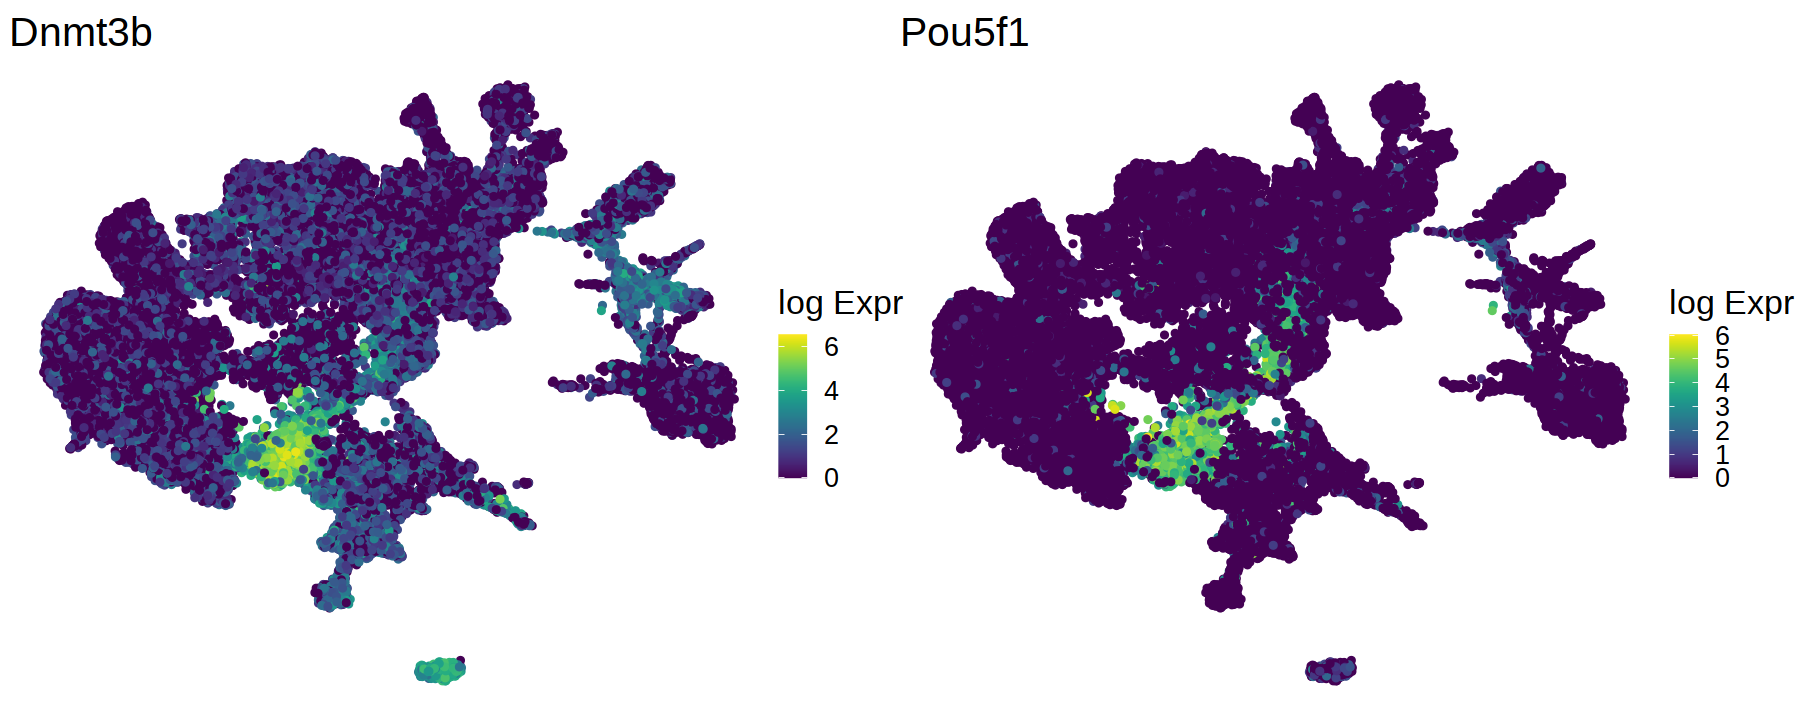

In [58]:
options(repr.plot.width=15, repr.plot.height=6)
plot_gene('Dnmt3b') + plot_gene('Pou5f1')

In [60]:
meta = as.data.table(colData(sce), keep.rownames=TRUE)

Warning message in .local(x, row.names, optional, ...):
“Arguments in '...' ignored”


In [89]:
plot_violin = function(gene, ct){
    ggplot(meta[celltype.mapped_mnn==ct], aes(stage, logcounts(sce)[gene,meta$celltype.mapped_mnn==ct], fill=stage)) + 
        geom_violin() + 
        geom_boxplot(fill='white', width = 0.05, outlier.shape=NA) +
        geom_point(size=0.01, alpha = 0.5, position=position_jitter(width=0.2)) + 
        ylab(paste0('Log ', gene, 'Expr')) + 
        ggtitle(gene,
               ct) + 
        scale_fill_manual(values=opts$stage.colors) +
        theme_bw() + theme(text = element_text(size = 20, color='black'))
    }

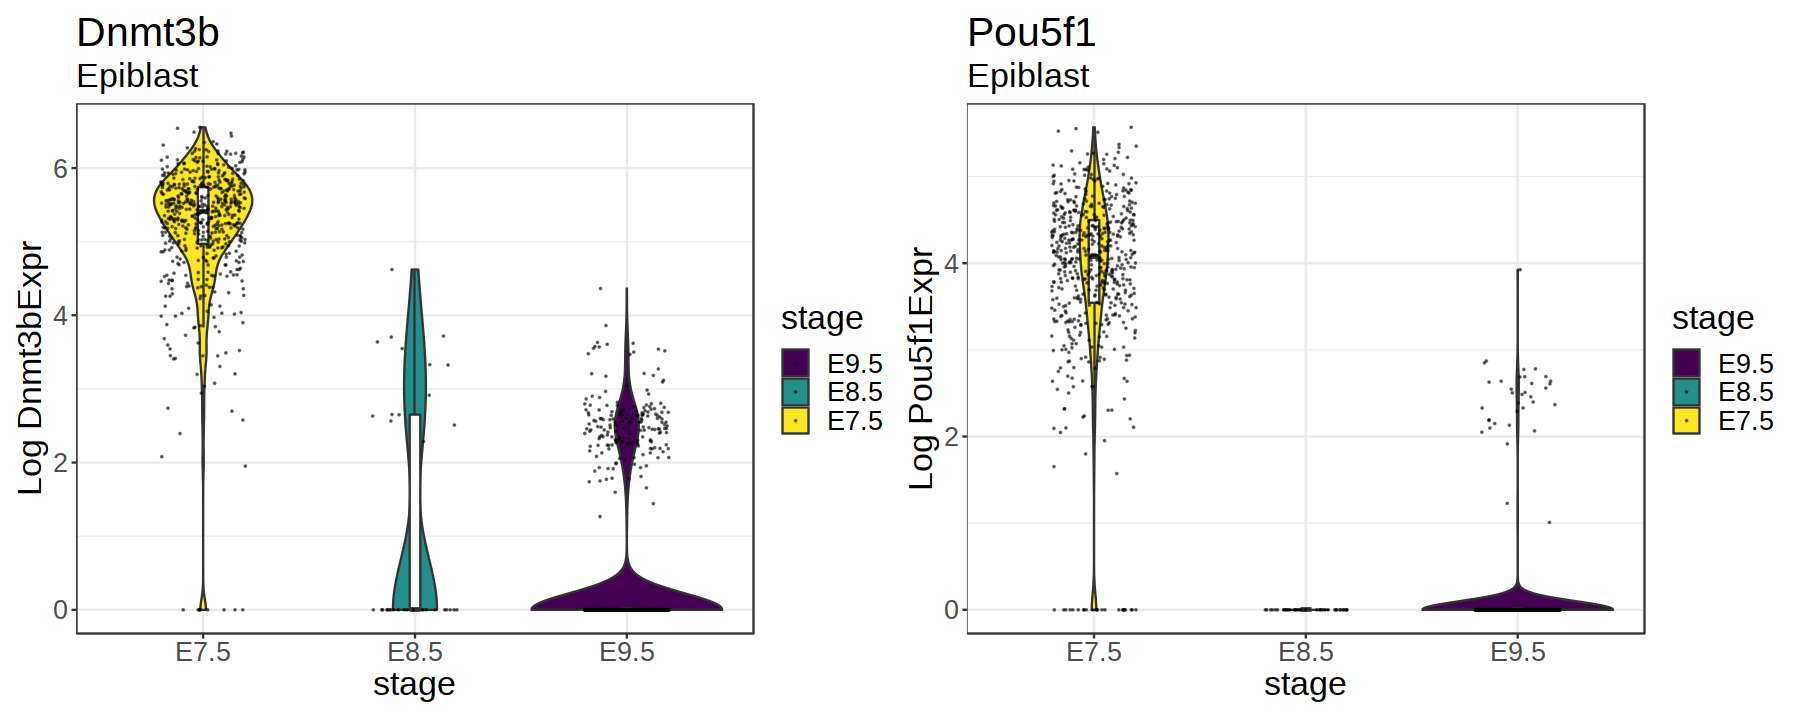

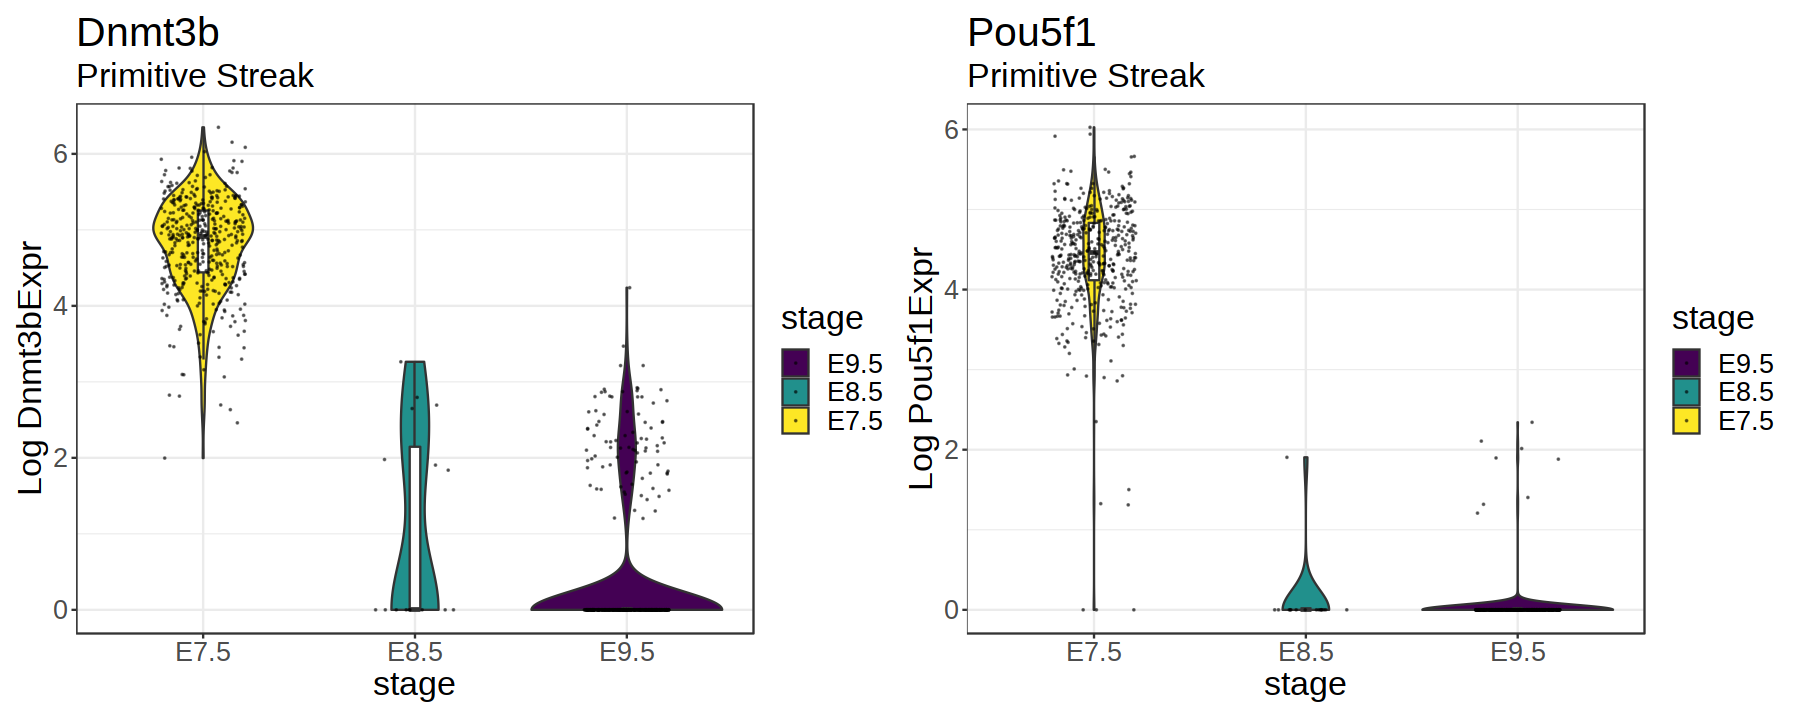

In [92]:
plot_violin(gene='Dnmt3b', ct='Epiblast') + plot_violin('Pou5f1', 'Epiblast')
plot_violin(gene='Dnmt3b', ct='Primitive Streak') + plot_violin('Pou5f1', 'Primitive Streak')